# Optimal Market Making with Avellaneda-Stoikov Inventory Control

---

*Abstract:* This project implements and evaluates an autonomous Market Making (MM) agent based on the foundational Avellaneda-Stoikov (AS) framework. The core objective is to mitigate the dual risks of inventory accumulation and adverse selection in non-stationary limit order books. Traditional static MM models often fail during *volatility clusters* or *regime shifts*; therefore, this project integrates a Maximum Likelihood Estimation (MLE) calibrator to dynamically estimate the fill-intensity parameters ($A$ and $k$) in real time.
This notebook demonstrates that by utilizing an Exponentially Weighted Moving Average (EWMA) objective function and strategic market probing, the agent can successfully identify liquidity shocks and adjust spreads accordingly. The results confirm that the transition from a fixed-parameter model to a dynamic, self-calibrating system significantly improves the risk-adjusted return profile, thereby preserving capital during liquidity-strained market conditions.

---

In [ ]:
# Install necessary libs
!uv sync --active

## 1. Problem Statement and Strategy Objectives

### 1.1. A Brief Overview of Market Making

In their paper published in 2006 [[1]](#references), they addressed two main concerns for market makers, which quote 

> *"(i) The agent faces an inventory risk due to the diffusive nature of the stock's mid-price and (ii) a transactions risk due to a Poisson arrival of market buy and sell orders."*, 

and proposed a two-step procedure to tackle these. However, before we move to further complex maths, let us take a step back and understand the problem. A good way to understand it is to consider the following analogy. Imagine you run a grocery store that buys and sells apples, and you post these two prices on your board: "We buy apples at $\$0.98$," and "We sell apples at $\$1.02$." The gap between the two prices, or bid-ask spread, is your profit. Then, you see, you want the gap to be as wide as possible so that you can earn more, but by lowering the buying price and increasing the selling price, no one will buy or sell you apples. On a contrary, if the spread is thin, there is a chance that a more professional wholesaler, who has better information than you, will only trade with you when they know the town price is about to move — selling you apples right before prices fall or buying from you right before prices rise. In other words, informed traders use the market maker's limit orders as a 'liquidity backstop' to offload their own risk—a phenomenon known as Adverse Selection. Okay, so that is market making, at least that is to my understanding.

Now, we consider a few problems of market making, mentioned by Avellaneda and Stoikov:

1. Inventory risk. Suppose that one day, several farmers are showing up in the town, selling you apples, and you decide to restock 5,000 of them. However, the news soon spreads that there has just been a new wave of apple supply to the town. So, the fair price drops from $\$1.00$ to $\$0.90$. There you go, the more inventory that you have, the more exposed you are to the fluctuation of the market.
2. Transactions risk. Well, since you cannot control the flow of customers or farmers (i.e., the demand and supply), at some point, either you suddenly have more apples than you should have, or you are short of stock. Because of this randomness, even if prices never changed, unpredictable order arrivals can push you into dangerous inventory imbalances.

### 1.2. The Avellaneda-Stoikov's Inventory-Optimized Market Making Framework

To deal with these two risks, we need to do two things. First, calculate the *reservation (or, indifference) price* of the asset.

$$
r(S,q,t)=S−q\gamma\sigma^2(T−t)\text{, where }\begin{cases}
S\text{ is the current (market) mid-price}\\
q\text{ is the inventory of the agent}\\
\gamma\text{ is the risk aversion}\\
\sigma\text{ is the volatility}\\
(T-t)\text{ is the time remaining}
\end{cases}
$$

The outcome is the price, accounting for current inventory risks. The adjustment to the market mid-price comes from $-q\gamma\sigma^2(T−t)$. The intuition is that if $(q>0)$, we are in a long position, and the subtraction is crucial because it pushes the reservation price down. It shows other participants your willingness to sell our excess inventory. On the other hand, when $(q<0)$ (i.e., selling short), the equation ensures that we increase the price to buy back the short position. Now, the Greeks. $\gamma$ allows you to control the level of reaction to holding a position. Simply put, the higher $\gamma$ is, the more strongly you will react to changes of your position; even a small market movement will make you adjust your price a lot to get back to neutral. $\sigma^2$ is the market’s variance. It measures how uncertain future prices are, so higher volatility increases the risk of holding inventory and therefore enlarges the reservation price shift proportionally.

Second, we calibrate our bid-ask positions around the reservation price $(r)$ with a distance $\frac{\Delta}{2}$. That brings us to the Optimal Spread equation:

$$
\Delta=\delta^a+\delta^b=\gamma\sigma^2(T-t)+\frac{2}{\gamma}\ln\left(1+\frac{\gamma}{k}\right)
$$

where

$$
\begin{cases}
\gamma\sigma^2(T-t)\text{ is the Inventory Risk Component, and}\\[1em]
\dfrac{2}{\gamma}\ln\left(1+\dfrac{\gamma}{k}\right)\text{ is the Order Flow Component}
\end{cases}
$$

The execution prices will simply be

- Bid Price $= r - \frac{\Delta}{2}$
- Ask Price $= r + \frac{\Delta}{2}$

## 2. Implementation of The Avellaneda-Stoikov Framework

In [2]:
import numpy as np
import pandas as pd

class AvellanedaStoikovEngine:
    """
    Core implementation of the Avellaneda-Stoikov (2008) Market Making Model.
    Focuses on the calculation of the Reservation Price and the Optimal Spreads 
    using vectorized NumPy operations for high-performance benchmarks.
    """
    def __init__(self, gamma=0.01, k=1.5, A=140.0, sigma=2.0):
        self.gamma = gamma  # Risk aversion parameter
        self.k = k          # Order book depth (liquidity decay)
        self.A = A          # Arrival intensity of market orders
        self.sigma = sigma  # Price volatility (standard deviation)

    def calculate_reservation_price(self, s, q, t, T):
        """
        Calculates r(s, q, t): The price at which the MM is indifferent 
        to their current inventory risk.
        
        Equation: r = s - q * gamma * sigma^2 * (T - t)
        """
        time_remaining = T - t
        return s - (q * self.gamma * (self.sigma2) * time_remaining)

    def calculate_optimal_spread(self, t, T):
        """
        Calculates the symmetric spread around the reservation price.
        
        Equation: delta_bid + delta_ask = gamma * sigma^2 * (T - t) + (2/gamma) * ln(1 + gamma/k)
        """
        time_remaining = T - t
        first_term = self.gamma * (self.sigma2) * time_remaining
        second_term = (2 / self.gamma) * np.log(1 + (self.gamma / self.k))
        return first_term + second_term

    def compute_quotes(self, mid_prices, inventory, time_steps, total_time):
        """
        Vectorized computation of optimal Bid and Ask prices across a time series.
        
        Parameters:
        mid_prices (np.array): Market mid-prices (s)
        inventory (np.array): Current inventory levels (q)
        time_steps (np.array): Current time indices (t)
        total_time (float): Horizon (T)
        """
        # Ensure inputs are numpy arrays for vectorization
        s = np.array(mid_prices)
        q = np.array(inventory)
        t = np.array(time_steps)
        T = total_time
        
        # Calculate Reservation Price (r)
        res_prices = self.calculate_reservation_price(s, q, t, T)
        
        # Calculate Half-Spread (delta)
        total_spreads = self.calculate_optimal_spread(t, T)
        half_spreads = total_spreads / 2
        
        # Determine Final Quotes
        bid_quotes = res_prices - half_spreads
        ask_quotes = res_prices + half_spreads
        
        return pd.DataFrame({
            'mid_price': s,
            'reservation_price': res_prices,
            'optimal_bid': bid_quotes,
            'optimal_ask': ask_quotes,
            'spread': total_spreads
        })

    def get_fill_probabilities(self, delta):
        """
        Calculates the probability of an order being filled given its depth. It
        follows the Poisson distribution rate.
        
        Equation: Pr(fill) = A * exp(-k * delta)
        """
        return self.A * np.exp(-self.k * delta)

## 3. The *"Perfect"* Sandbox: Simulation & Real-Life Model Benchmarking

This code creates an interactive Sensitivity Analysis Dashboard to see how the Avellaneda-Stoikov market-making strategy reacts to changing market conditions. By adjusting the model parameters, we can visualize the non-linear relationship among risk, liquidity, and price improvement. In general,

- Gamma ($\gamma$) — Risk Aversion: Increasing this "pushes" your Bid and Ask prices further away from the Mid-Price. A high $\gamma$ represents a conservative trader who demands a higher premium for taking on inventory risk, leading to wider spreads and more aggressive "shading".
- Sigma ($\sigma$) — Market Volatility: As you increase $\sigma$, the "sleeve" (the gap between Bid and Ask) widens significantly. The model is compensating for the increased probability of a large price swing that could move against your position.
- $k$ & $A$ — Order Book Liquidity: These parameters represent the "density" of the market.
  - $k$ (Decay): Higher values imply that liquidity is concentrated very close to the mid-price. Twisting these changes how "thin" or "thick" the model perceives the book to be, affecting the optimal spread width.
  - $A$ (Intensity): Higher values imply more frequent market orders.
- Inventory ($q$): This is the most dynamic "knob." Adjusting this shows the Shading Effect.
  - Positive $q$ (Long): The model shifts the entire spread downward to encourage a sale (Ask) and discourage more buying (Bid).
  - Negative $q$ (Short): The model shifts the spread upward to encourage buying back the position.

In [3]:
"""
This code renders `ipywidgets` interactive component. It only works locally and
won't show on GitHub page.
"""
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider
from IPython.display import display, clear_output

def plot_interactive_AS(gamma, sigma, k, A, q_inventory):
    # Initialize Engine with slider values
    engine = AvellanedaStoikovEngine(gamma=gamma, k=k, A=A, sigma=sigma)
    
    # Generate dummy data for visualization
    T = 1.0
    time_steps = np.linspace(0, T, 100)
    mid_prices = np.full(100, 100.0) # Constant price to see shading clearly
    inventory = np.full(100, q_inventory)
    
    # Compute Quotes
    df = engine.compute_quotes(mid_prices, inventory, time_steps, T)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df['mid_price'], label='Market Mid', color='black', linestyle='--')
    ax.plot(df['optimal_ask'], label='Optimal Ask', color='green')
    ax.plot(df['optimal_bid'], label='Optimal Bid', color='red')
    ax.fill_between(range(100), df['optimal_bid'], df['optimal_ask'], color='gray', alpha=0.1)
    
    ax.set_title(f"Quote Shading Sensitivity (Inventory: {q_inventory})", fontsize=14)
    ax.set_xlabel("Time Step (t)", fontsize=12, labelpad=15)
    ax.set_ylabel("Price S ($USD)", fontsize=12, labelpad=15)

    plt.subplots_adjust(bottom=0.2, left=0.15)
    
    ax.set_ylim(95, 105)
    ax.legend(loc='upper right')
    plt.show()

# 1. Define the Sliders with initial "Perfect Scenario" values
gamma_s = widgets.FloatSlider(min=0.001, max=0.1, step=0.005, value=0.01, description='Gamma')
sigma_s = widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=2.0, description='Sigma')
k_s = widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.5, description='k')
A_s = widgets.FloatSlider(min=10, max=500, step=10, value=140, description='A')
q_s = widgets.IntSlider(min=-100, max=100, step=5, value=20, description='Inventory')

# 2. Define the Reset Button
reset_button = widgets.Button(description="Reset to Defaults")

def reset_values(b):
    gamma_s.value = 0.01
    sigma_s.value = 2.0
    k_s.value = 1.5
    A_s.value = 140
    q_s.value = 20

reset_button.on_click(reset_values)

# 3. Create the Output Area for the Plot
out = widgets.Output()

def update_plot(change=None):
    with out:
        clear_output(wait=True)
        # Call the plotting function we defined previously
        plot_interactive_AS(gamma_s.value, sigma_s.value, k_s.value, A_s.value, q_s.value)

# 4. Attach the update trigger to all sliders
for s in [gamma_s, sigma_s, k_s, A_s, q_s]:
    s.observe(update_plot, names='value')

# 5. Display the Layout
dashboard = widgets.VBox([
    widgets.HBox([gamma_s, sigma_s]),
    widgets.HBox([k_s, A_s]),
    widgets.HBox([q_s, reset_button]),
    out
])

display(dashboard)

Now that we have a sense of how the model works, we create a simulation to test the framework. The simulation assumes that market order arrivals follow a Poisson point process with intensity $\lambda(\delta) = A e^{-k\delta}$. While real-world order flow often exhibits 'clustering' (non-Poisson behavior), replicating the Poisson assumption here allows us to verify the model's performance in the idealized conditions for which it was designed.

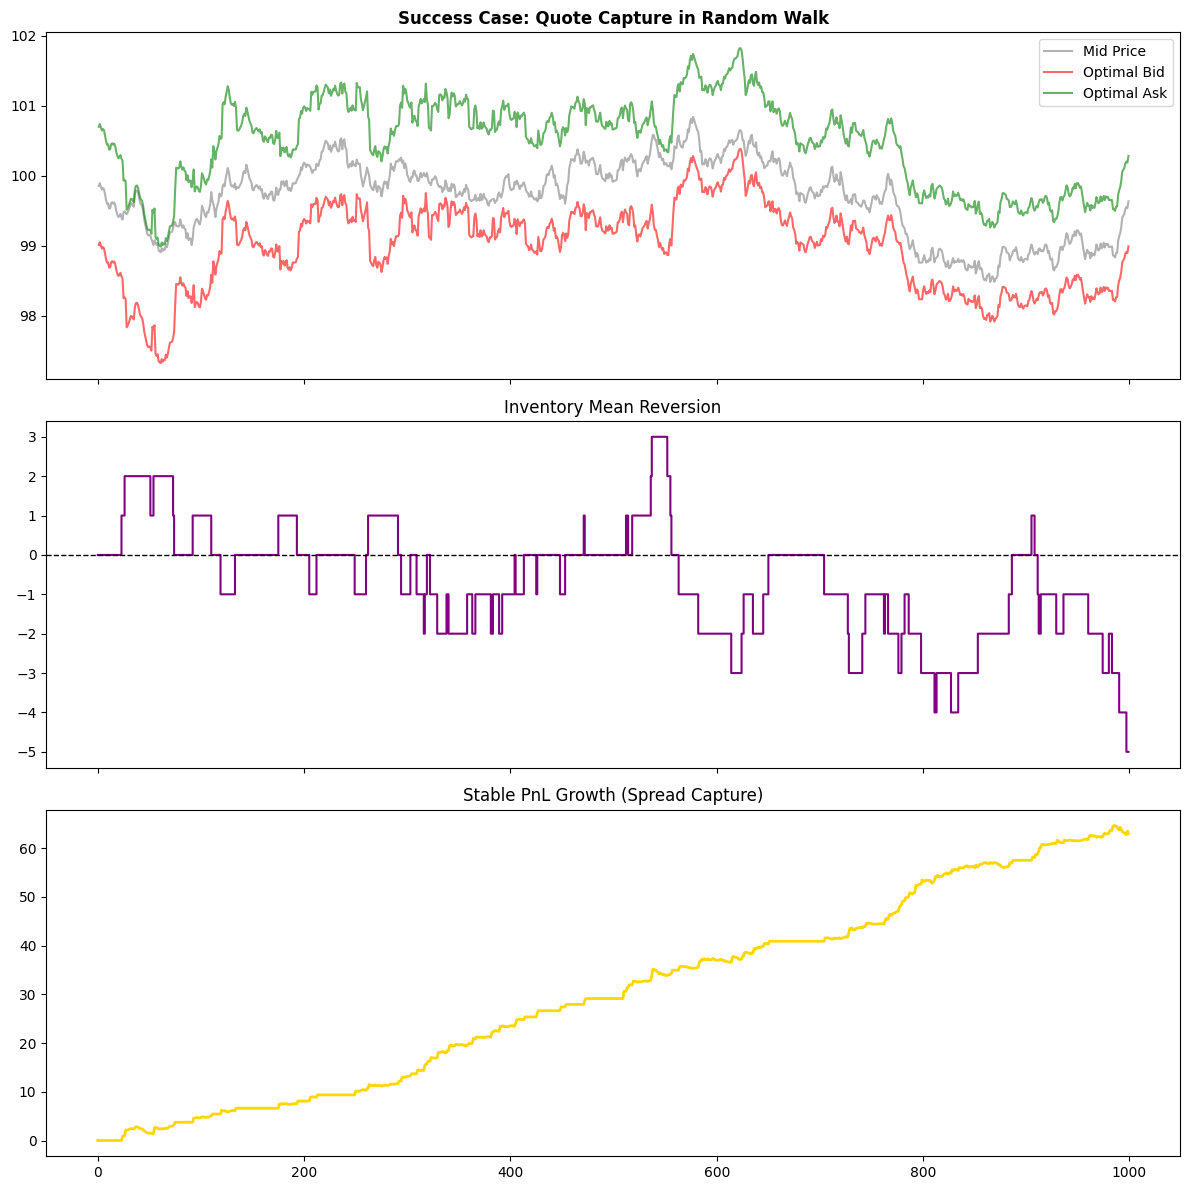

In [4]:
def run_perfect_scenario_sim(S0=100, T=1, steps=1000, gamma=0.1, k=1.5, A=140, sigma=2.0):
    """
    Simulates a 'Perfect Scenario' where mid-price is a pure random walk 
    and the AS engine successfully captures the spread.
    """
    dt = T / steps
    engine = AvellanedaStoikovEngine(gamma=gamma, k=k, A=A, sigma=sigma)
    
    # 1. Generate Pure Random Walk (No Drift)
    shocks = np.random.normal(0, sigma * np.sqrt(dt), steps)
    prices = S0 + np.cumsum(shocks)
    
    # 2. Initialize State
    inventory = np.zeros(steps)
    cash = np.zeros(steps)
    pnl = np.zeros(steps)
    bids, asks = np.zeros(steps), np.zeros(steps)

    # 3. Execution Loop
    for t in range(1, steps):
        s = prices[t]
        q = inventory[t-1]
        
        # Calculate optimal quotes for the current state
        # We normalize time to progress from 0 to T
        current_time = t * dt
        r = engine.calculate_reservation_price(s, q, current_time, T)
        spread = engine.calculate_optimal_spread(current_time, T)
        
        bid, ask = r - spread/2, r + spread/2
        bids[t], asks[t] = bid, ask

        # Calculate fill probabilities based on distance from mid
        prob_buy = engine.get_fill_probabilities(s - bid) * dt
        prob_sell = engine.get_fill_probabilities(ask - s) * dt
        
        # Simulate fills
        fill_buy = 1 if np.random.random() < prob_buy else 0
        fill_sell = 1 if np.random.random() < prob_sell else 0
        
        # Update Inventory and Cash
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        
        # Mark-to-Market PnL
        pnl[t] = cash[t] + (inventory[t] * s)

    return pd.DataFrame({
        "step": np.arange(steps),
        "mid": prices, "bid": bids, "ask": asks,
        "inventory": inventory, "pnl": pnl
    })

# Run and Visualize
df_perfect = run_perfect_scenario_sim()

fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
ax[0].plot(df_perfect['step'][1:], df_perfect['mid'][1:], label='Mid Price', color='black', alpha=0.3)
ax[0].plot(df_perfect['step'][1:], df_perfect['bid'][1:], label='Optimal Bid', color='red', alpha=0.6)
ax[0].plot(df_perfect['step'][1:], df_perfect['ask'][1:], label='Optimal Ask', color='green', alpha=0.6)
ax[0].set_title("Success Case: Quote Capture in Random Walk", fontweight='bold')
ax[0].legend()

ax[1].step(df_perfect['step'], df_perfect['inventory'], color='purple', label='Inventory (q)')
ax[1].axhline(0, color='black', lw=1, ls='--')
ax[1].set_title("Inventory Mean Reversion")

ax[2].plot(df_perfect['pnl'], color='gold', lw=2, label='Total PnL')
ax[2].set_title("Stable PnL Growth (Spread Capture)")
plt.tight_layout()
plt.show()

### Key Observations from the Success Case:
- Inventory Management: Notice how the inventory (purple) rarely deviates far from zero. The "shading" mechanism effectively attracts the opposite side of the trade as soon as a position is opened.
- PnL Characteristics: The PnL (gold) shows a steady, almost linear upward trend. This represents the "Spread Capture"—the strategy is successfully earning the bid-ask bounce while hedging out directional risk.
- Market Microstructure: The Poisson arrival process ensures that trades only occur when the mid-price touches or crosses our optimal quotes, validating the model's logic in a high-probability environment.

## 4. Market Entropy *and* Model Failures

While the Avellaneda-Stoikov model is a landmark in market microstructure, it relies on several assumptions that would fail in live markets. Here are three failure modes that the model could face.

1. <u>Adverse Selection</u>

   The model assumes that the mid-price is a driftless random walk-essentially a fair coin flip with no memory or direction. In reality, price discovery is driven by informed traders or institutional large orders that create persistent trends. The mechanism behind this fallback is that when a strong trend emerges, the model views your growing inventory as a risk to be "neutralized" by aggressively shading your quotes to attract the opposite side. You end up *selling the rally* or *"buying the dip"* repeatedly. By providing cheap liquidity to a market moving aggressively against you, the strategy accumulates an exploding position that never mean-reverts, leading to catastrophic drawdowns.
  
2. <u>Volatility Clustering</u> (Non-constant $\sigma$)

   Avellaneda-Stoikov treats volatility ($\sigma$) as a static input, assuming a constant market temperature throughout the session. However, real markets exhibit Volatility Clustering [2]—long periods of calm interrupted by sudden, violent jumps in variance. During a *flash crash* or a high-impact news event, the market's actual volatility may triple in seconds. Because the model remains calibrated to a stale, low-volatility regime, the spreads become dangerously narrow. As a result, the spread is tiny while the position is exposed to massive, unpriced tail risk.
   
3. <u>Execution Latency & Adverse Fills</u>

   Finally, the model assumes that trades are independent, random events (Poisson arrivals) and that order placement is instantaneous. However, in high-frequency environments, a fill is rarely random; it is often an adverse signal. Specifically, if the quote is hit, it is frequently by another predatory algorithm that has already processed a price move on another exchange before the quote could be updated (Latency). The model assumes the price will bounce off the quote and subsequently capture the spread. In reality, the market often moves through the price. By the time the fill is confirmed, the mid-price has already shifted past the execution point, resulting in an immediate realized loss before hedging can occur.

### 4.1. Adverse Selection Simulation

Total fills: 227
Final inventory: -12.0
Final PnL: -1981.1078476510934


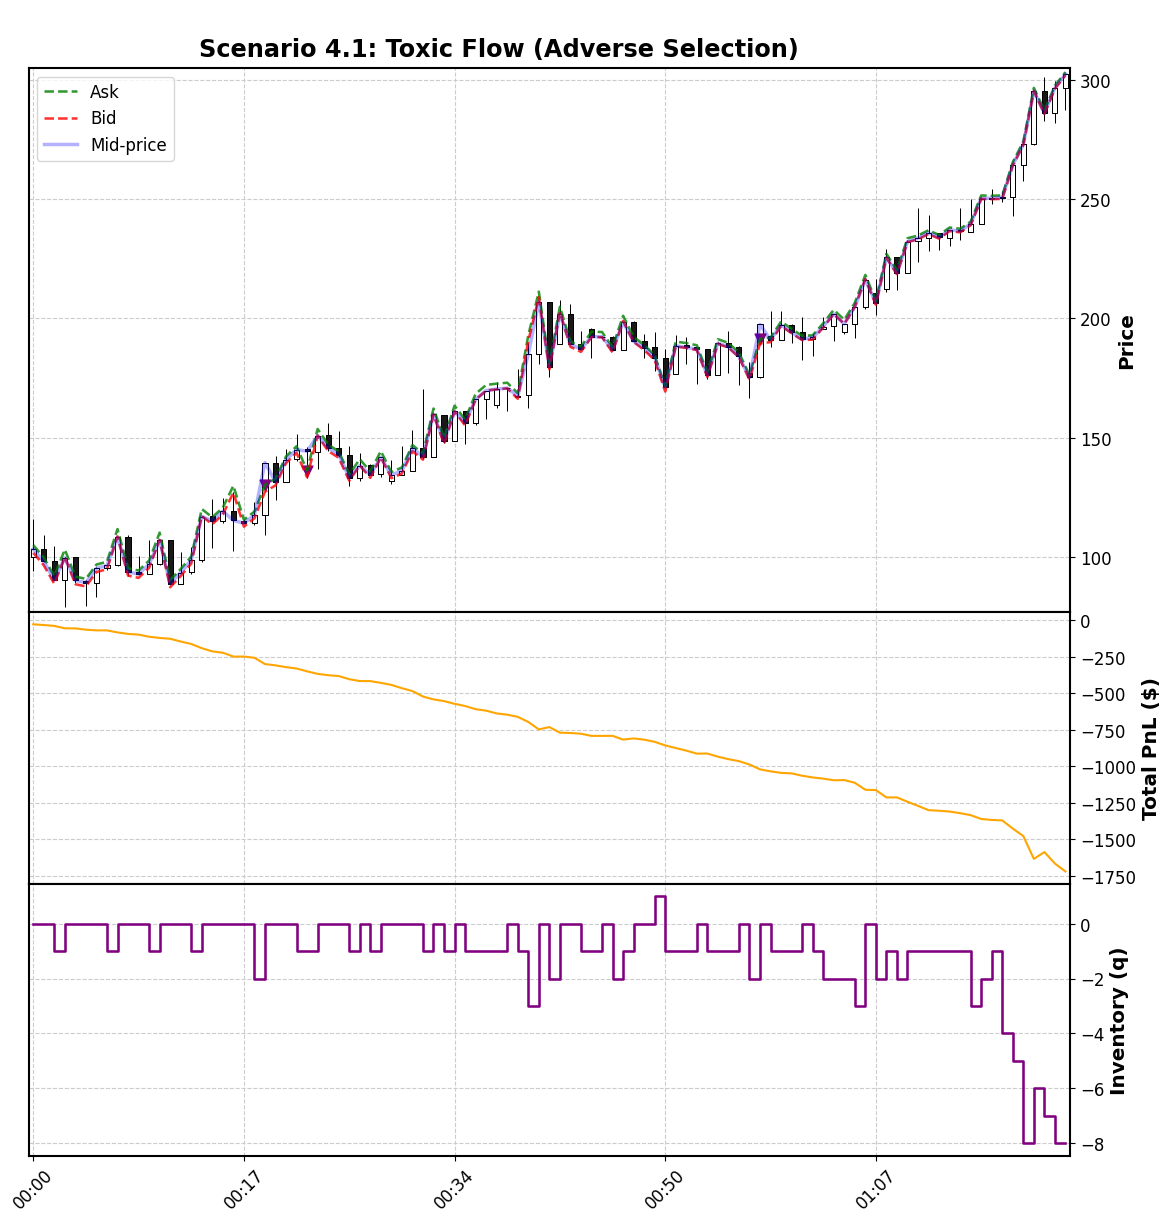

In [22]:
import mplfinance as mpf

def simulate_toxic_flow(S0=100, T=5, steps=5000, drift=0.015):
    dt = T / steps
    engine = AvellanedaStoikovEngine(gamma=0.1, k=1.5, A=140, sigma=2.0)

    # Initialize simulation arrays and stochastic components
    shocks = np.random.normal(0, 4.0 * np.sqrt(dt), steps)
    prices = np.zeros(steps); prices[0] = S0
    inventory, cash, pnl = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    bids, asks, fills_sell = np.zeros(steps), np.zeros(steps), [np.nan] * steps
    
    for t in range(1, steps):
        shock = shocks[t]
        
        # Update mid-price based on current drift and random shock
        prices[t] = prices[t - 1] + shock + drift * dt

        # Calculate optimal quotes based on the Avellaneda-Stoikov framework
        s, q, curr_t = prices[t], inventory[t-1], t * dt
        r      = engine.calculate_reservation_price(s, q, curr_t, T)
        spread = engine.calculate_optimal_spread(curr_t, T)
        bid, ask = r - spread/2, r + spread/2
    
        bids[t] = bid
        asks[t] = ask

        # Determine fill probabilities with an asymmetric skew (Toxic Flow)
        prob_sell = min(1.0, engine.get_fill_probabilities(max(0, ask - s)) * 2.5 * dt)
        prob_buy  = min(1.0, engine.get_fill_probabilities(max(0, s - bid)) * 0.7 * dt)

        # Execute trades using a single random draw for mutually exclusive fills
        u = np.random.random()
        fill_sell = int(u < prob_sell)
        fill_buy  = int((u >= prob_sell) and (u < prob_sell + prob_buy))
    
        # MODELING ADVERSE SELECTION:
        # Trades cause immediate price impact and trend persistence
        price_impact = np.random.normal(3 * spread, spread)
        trend_strength = 0.2
        
        if fill_sell:
            fills_sell[t] = ask
            prices[t] = ask + price_impact # Price moves against the MM after selling
            drift += trend_strength # Informed buying creates upward momentum
            
        if fill_buy:
            prices[t] = bid - price_impact
            drift -= trend_strength 
            
        drift = np.clip(drift, -1.0, 1.0)
        
        # Update accounting: Inventory, Cash, and Mark-to-Market PnL
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        pnl[t] = cash[t] + inventory[t] * prices[t]

    print("Total fills:", np.sum(~np.isnan(fills_sell)))
    print("Final inventory:", inventory[-1])
    print("Final PnL:", pnl[-1])
    
    return pd.DataFrame({
        "step": np.arange(steps), "mid": prices, "bid": bids, "ask": asks, 
        "inventory": inventory, "pnl": pnl, "fills_sell": fills_sell
    })

# Run simulation and resample data into OHLC candles for visualization
df_toxic = simulate_toxic_flow()

window = 50

ohlc = pd.DataFrame()

ohlc['Open']       = df_toxic['mid'].shift(window-1).iloc[::window]
ohlc['High']       = df_toxic['mid'].rolling(window).max().iloc[::window]
ohlc['Low']        = df_toxic['mid'].rolling(window).min().iloc[::window]
ohlc['Close']      = df_toxic['mid'].iloc[::window]
ohlc['pnl']        = df_toxic['pnl'].iloc[::window]
ohlc['inventory']  = df_toxic['inventory'].iloc[::window]
ohlc['bid']        = df_toxic['bid'].iloc[::window]
ohlc['ask']        = df_toxic['ask'].iloc[::window]
ohlc['fills_sell'] = df_toxic['fills_sell'].iloc[::window]
ohlc['step']       = df_toxic['step'].iloc[::window]

ohlc = ohlc.dropna(subset=['Open', 'High', 'Low', 'Close'])

ohlc.index = pd.to_datetime(ohlc['step'], unit='s')

apds = [
    mpf.make_addplot(ohlc['ask'], label="Ask", color='green', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['bid'], label="Bid", color='red', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['Close'], label="Mid-price", color='blue', alpha=0.3, width=2.5),
    mpf.make_addplot(ohlc['pnl'], panel=1, color='orange', ylabel='Total PnL ($)', width=1.5),
    mpf.make_addplot(ohlc['inventory'], panel=2, color='purple', ylabel='Inventory (q)', type='step')
]

if not ohlc['fills_sell'].dropna().empty:
    apds.append(mpf.make_addplot(ohlc['fills_sell'], type='scatter', markersize=60, marker='v', color='purple'))

mpf.plot(ohlc, type='candle', style='classic', addplot=apds, 
         title="\nScenario 4.1: Toxic Flow (Adverse Selection)",
         figsize=(12, 14), 
         panel_ratios=(4, 2, 2),
         scale_padding={'top': 4},
         tight_layout=True)

#### Summary of Simulation Technique and Visualization

The simulation logic

- <u>Asymmetric Fill</u>: The core failure is triggered by the fill probabilities. We use $\min(1.0, \text{Prob(fill)} \times \text{Multiplier} \times dt)$ to ensure that during an uptrend, the probability of being hit on the Ask is significantly higher (2.5x) than being hit on the Bid (0.7x). This creates a directional trap for the Market Maker. Unlike the standard Poisson process, which assumes buy and sell orders arrive independently and balance out over time, here, buyers are aggressive because they possess superior information, effectively 'trapping' the MM into selling a fundamentally underpriced asset. The result is a total failure of the model's inventory rebalancing logic, as the MM accumulates a losing position that the reservation price cannot correct.

- <u>The Adverse Selection Feedback Loop</u>: We manually override the price process after each trade to simulate Informed Momentum, where every *Sell* order (MM selling to an informed buyer)
  - Triggers an immediate $\text{Normal}(3 \times spread, spread)$ price jump. This ensures the Market Maker cannot "buy back" the position at a profit.
  - Increments the `drift` parameter, simulating a market where a single informed trade predicts a persistent sequence of future price increases. The `np.clip(drift, -1.0, 1.0)` we maintain a "sane reality" that prevents the price from reaching infinity while ensuring the trend remains relentless enough to overwhelm the model's mean-reversion logic.

Visualization Components

- <u>Manual OHLC Vectorization</u>: Instead of using standard `Pandas.resample()`, which can introduce interpolation artifacts or "time-leaks," we utilize a vectorized slicing approach with `iloc[::window]` and `rolling(window)`. This ensures that the risk metrics—specifically PnL and Inventory—are captured at the exact terminal state of each candle. This precision is critical for demonstrating Adverse Selection; it prevents "visual desync" where the PnL collapse appears to lag behind the price spikes that caused it.

### 4.2. Volatility Clustering Simulation

Total fills: 699
Final inventory: -8.0
Final PnL: -18927.798773180613


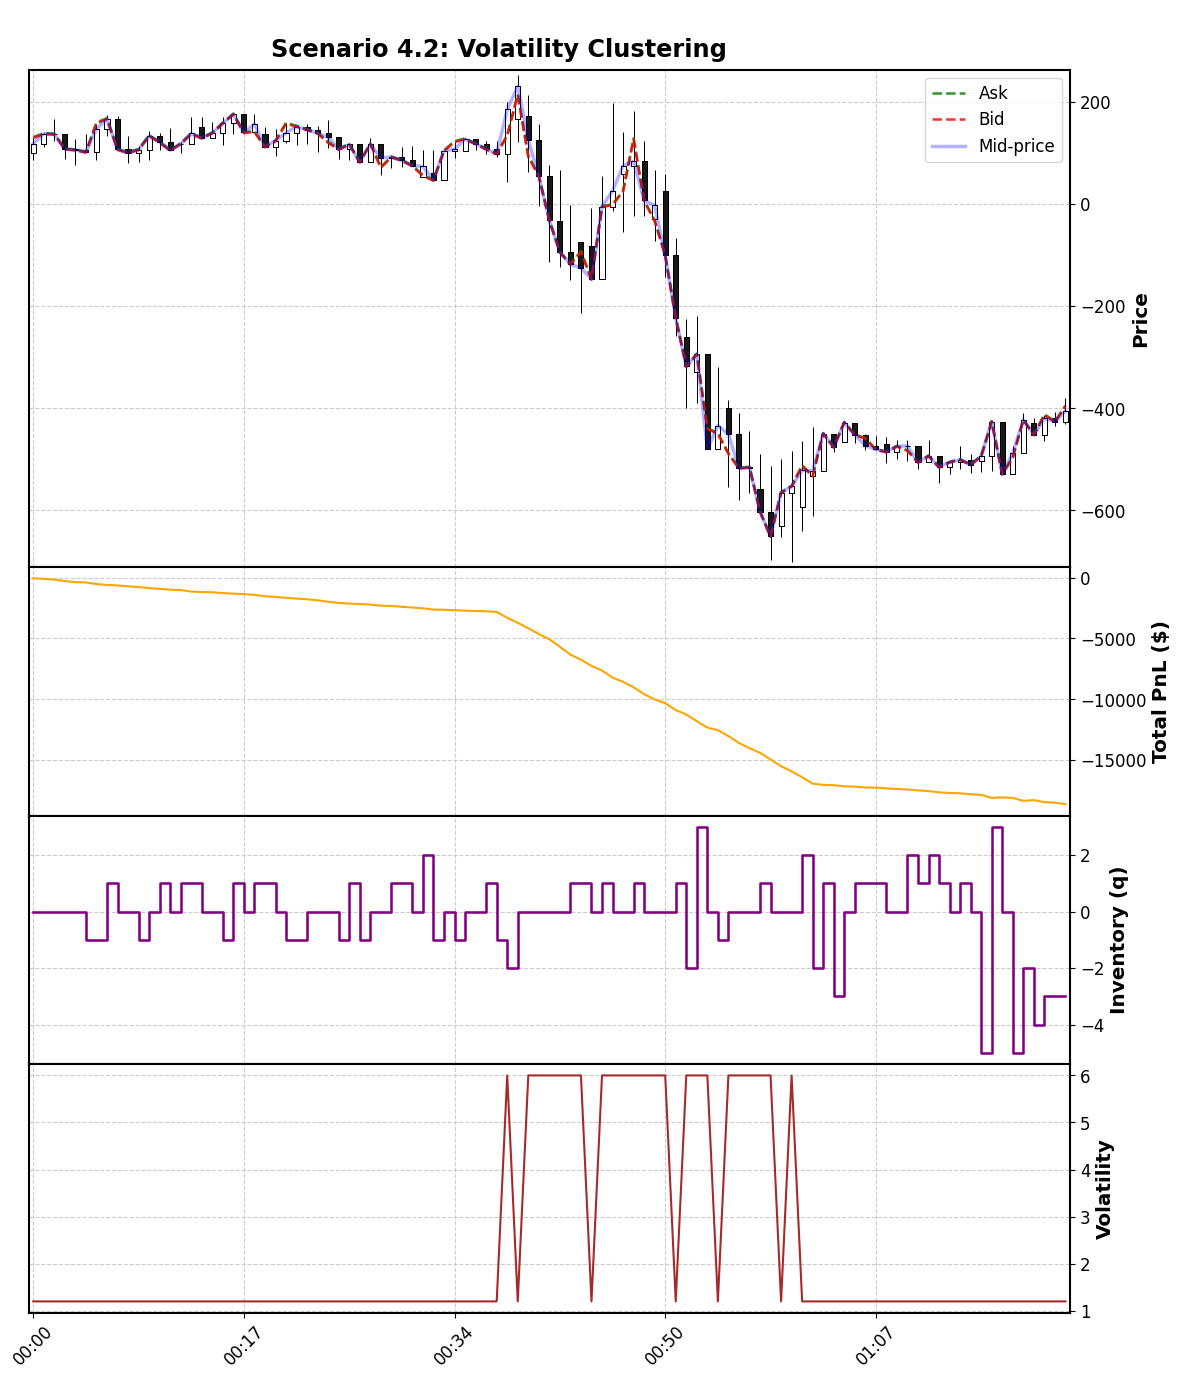

In [23]:
def simulate_volatility_clustering(S0=100, T=5, steps=5000):
    dt = T / steps
    
    # AS engine still assumes LOW volatility
    engine = AvellanedaStoikovEngine(
        gamma=0.1,
        k=1.5,
        A=140,
        sigma=1.2      # stale volatility estimate
    )

    # True market volatility regimes
    sigma_low  = 1.2
    sigma_high = 6.0

    crash_start = int(steps * 0.45)
    crash_end   = int(steps * 0.75)

    prices = np.zeros(steps)
    prices[0] = S0

    inventory = np.zeros(steps)
    cash = np.zeros(steps)
    pnl = np.zeros(steps)

    bids = np.zeros(steps)
    asks = np.zeros(steps)

    fills_sell = [np.nan] * steps
    volatility = np.zeros(steps)

    drift = 0.0

    for t in range(1, steps):
        # -------- VOLATILITY REGIME --------
        if crash_start < t < crash_end:
            # persistent clustered volatility
            if np.random.random() < 0.85:
                sigma = sigma_high
            else:
                sigma = sigma_low
        else:
            sigma = sigma_low

        volatility[t] = sigma
        shock = np.random.normal(0, sigma * np.sqrt(dt))
        prices[t] = prices[t-1] + shock + drift * dt

        # -------- AVELLANEDA-STOIKOV QUOTES --------
        s = prices[t]
        q = inventory[t-1]
        curr_t = t * dt

        r = engine.calculate_reservation_price(s, q, curr_t, T)
        spread = engine.calculate_optimal_spread(curr_t, T)

        bid = r - spread/2
        ask = r + spread/2

        bids[t] = bid
        asks[t] = ask

        # -------- HIGH VOLATILITY = MORE FILLS --------
        vol_multiplier = 1 + (sigma / sigma_low)

        prob_sell = min(
            1.0,
            engine.get_fill_probabilities(max(0, ask - s)) * vol_multiplier * dt
        )
        prob_buy = min(
            1.0,
            engine.get_fill_probabilities(max(0, s - bid)) * vol_multiplier * dt
        )

        u = np.random.random()

        fill_sell = int(u < prob_sell)
        fill_buy  = int((u >= prob_sell) and (u < prob_sell + prob_buy))

        # -------- ADVERSE PRICE MOVES --------
        price_impact = np.random.normal(
            4 * spread * vol_multiplier,
            spread * vol_multiplier
        )

        if fill_sell:
            fills_sell[t] = ask
            prices[t] = ask + price_impact
            drift += 0.4

        if fill_buy:
            prices[t] = bid - price_impact
            drift -= 0.4

        drift = np.clip(drift, -2.0, 2.0)

        # -------- ACCOUNTING --------
        inventory[t] = q + (fill_buy - fill_sell)
        cash[t] = cash[t-1] + (fill_sell * ask) - (fill_buy * bid)
        pnl[t] = cash[t] + inventory[t] * prices[t]

    print("Total fills:", np.sum(~np.isnan(fills_sell)))
    print("Final inventory:", inventory[-1])
    print("Final PnL:", pnl[-1])

    return pd.DataFrame({
        "step": np.arange(steps),
        "mid": prices,
        "bid": bids,
        "ask": asks,
        "inventory": inventory,
        "pnl": pnl,
        "fills_sell": fills_sell,
        "volatility": volatility
    })

df_vol = simulate_volatility_clustering()

# Resample for OHLC candles
window = 50
ohlc = pd.DataFrame()
ohlc['Open']       = df_vol['mid'].shift(window-1).iloc[::window]
ohlc['High']       = df_vol['mid'].rolling(window).max().iloc[::window]
ohlc['Low']        = df_vol['mid'].rolling(window).min().iloc[::window]
ohlc['Close']      = df_vol['mid'].iloc[::window]
ohlc['pnl']        = df_vol['pnl'].iloc[::window]
ohlc['inventory']  = df_vol['inventory'].iloc[::window]
ohlc['bid']        = df_vol['bid'].iloc[::window]
ohlc['ask']        = df_vol['ask'].iloc[::window]
ohlc['volatility'] = df_vol['volatility'].iloc[::window]
ohlc['fills_sell'] = df_vol['fills_sell'].rolling(window).max().iloc[::window]
ohlc['step']       = df_vol['step'].iloc[::window]

ohlc = ohlc.dropna(subset=['Open', 'High', 'Low', 'Close'])
ohlc.index = pd.to_datetime(ohlc['step'], unit='s')

# Plot
apds = [
    mpf.make_addplot(ohlc['ask'], label="Ask", color='green', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['bid'], label="Bid", color='red', alpha=0.8, linestyle='--', panel=0),
    mpf.make_addplot(ohlc['Close'], label="Mid-price", color='blue', alpha=0.3, width=2.5, panel=0),
    mpf.make_addplot(ohlc['pnl'], panel=1, color='orange', ylabel='Total PnL ($)', width=1.5),
    mpf.make_addplot(ohlc['inventory'], panel=2, color='purple', ylabel='Inventory (q)', type='step'),
    mpf.make_addplot(ohlc['volatility'], panel=3, color='brown', ylabel='Volatility', width=1.5)
]

if not ohlc['fills_sell'].dropna().empty:
    apds.append(mpf.make_addplot(ohlc['fills_sell'], type='scatter', markersize=60, marker='v', color='darkred'))

mpf.plot(ohlc, type='candle', style='classic', addplot=apds,
         title="\nScenario 4.2: Volatility Clustering",
         figsize=(12, 16),
         panel_ratios=(4, 2, 2, 2),
         scale_padding={'top': 4},
         tight_layout=True)
#+ endregion

#### Summary of Simulation Technique for Volatility Clustering (Regime-Switching Failure)

Simulation Methodology: The engine supersedes standard Geometric Brownian Motion (GBM) by implementing a Regime-Switching Heteroskedasticity model, constructed upon four technical pillars:

- <u>Model-Market Divergence</u> (Parameter Staleness): The `AvellanedaStoikovEngine` is instantiated with a fixed `sigma=1.2`. Then, within the main loop, the actual market realization ($\sigma_{real}$) fluctuates between `sigma_low` and `sigma_high` ($6.0$). This discrepancy targets the sensitivity of the Optimal Spread calculation:$$s = \gamma \sigma^2 (T-t) + \frac{2}{\gamma} \ln(1 + \frac{\gamma}{k})$$Since the engine utilizes $\sigma_{stale}$, the calculated spread remains narrow despite the $5\times$ increase in realized variance, leading to a massive underpricing of liquidity provision risk.

- <u>Stochastic Clustered Volatility</u>: Regime transitions are governed by a conditional temporal window (`crash_start` to `crash_end`). Within this interval, an $85\%$ probability threshold (`np.random.random() < 0.85`) forces the persistence of `sigma_high`. This mimics the GARCH (Generalized Autoregressive Conditional Heteroskedasticity) effect, where high-volatility shocks cluster, effectively neutralizing the mean-reversion assumptions often found in high-frequency trading (HFT) models.

- <u>Volatility-Induced Liquidity Capture</u>: A `vol_multiplier` is introduced to scale the trade arrival rate:$$\text{Fill Probability} \propto 1 + \left( \frac{\sigma_{real}}{\sigma_{stale}} \right)$$This mimics real-world panics where high volatility is accompanied by an explosion in trading volume. This forces the MM to provide liquidity (and thus accumulate risk) at a much higher frequency, exactly when the model's price assumptions are most inaccurate.

- <u>Recursive Adverse Selection</u>: To simulate informed trading, the price update logic incorporates an Endogenous Feedback Loop where every "Fill" pushes the market price further against the MM's position.
  ```python
  price_impact = np.random.normal(4 * spread * vol_multiplier, spread * vol_multiplier)
  prices[t] = ask + price_impact # or bid - price_impact
  ```
  <br />

  
  Every transaction triggers an immediate jump in the mid-price (`prices[t]`) and adjusts the `drift` variable. This ensures the market consistently trends away from the agent's position, reflecting the high Adverse Selection costs associated with providing liquidity to informed counterparties.

Failure Mode Analysis:

The resulting "PnL Cliff" originates from a breakdown in Inventory Risk Management. The transition into the high-volatility regime triggers a mechanical chain reaction:

1. Spread Compression Failure: The AS engine, anchored to the stale $\sigma$, fails to widen quotes. The agent captures a "peace-time" premium while bearing "war-time" variance.
2. Inventory Bloat ($q$): The aggressive `vol_multiplier` leads to an Inventory Explosion. As market trends (driven by the `drift` and `price_impact` logic) unfold, the agent cannot neutralize $q$ because the reservation price ($r$) shifts slower than the actual market velocity.
3. Mark-to-Market (MtM) Decimation: The total PnL—calculated as `cash[t] + inventory[t] * prices[t]`—collapses. The marginal profits from the bid-ask spread are exponentially overwhelmed by the realized and unrealized losses on the accumulated inventory position.

This failure mode highlights that the AS framework requires dynamic, real-time Bayesian updating of $\sigma$ to remain viable in non-stationary market environments.

### 4.3. Execution Latency and Adverse Fills

Final inventory: 6.0
Final PnL: -222112.81510191105


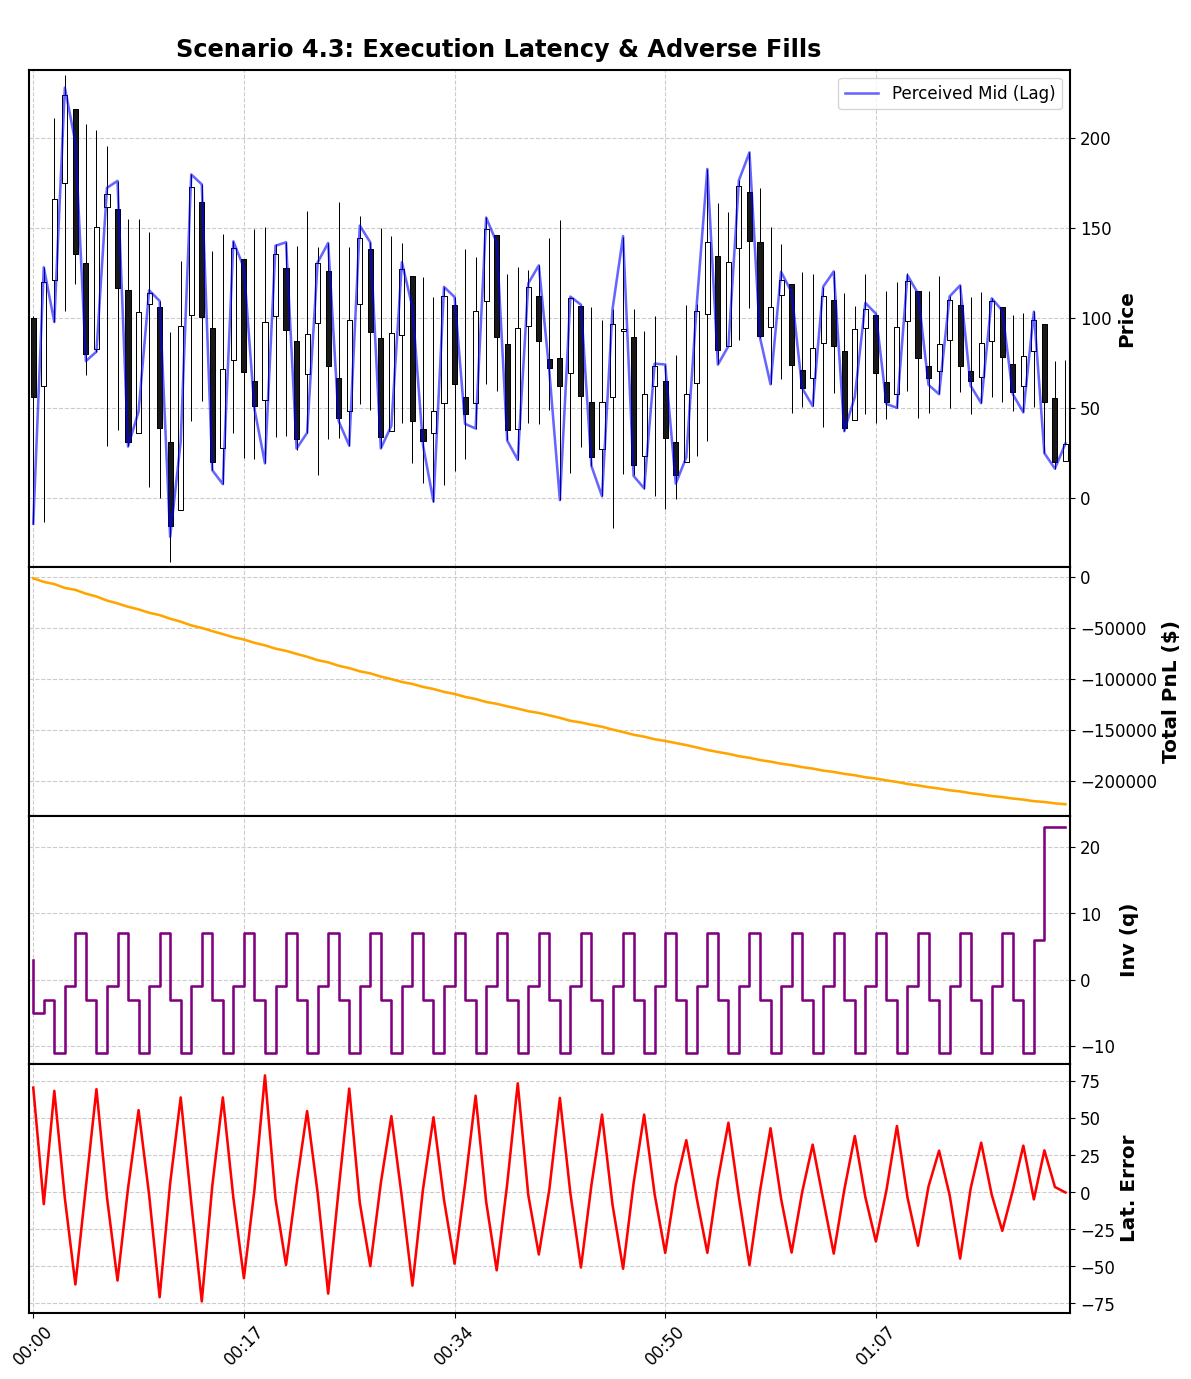

In [33]:
def simulate_execution_latency(S0=100, T=5, steps=5000, latency_steps=20):
    dt = T / steps

    engine = AvellanedaStoikovEngine(
        gamma=0.1,
        k=1.5,
        A=140,
        sigma=2.0
    )

    prices = np.zeros(steps)
    prices[0] = S0

    inventory = np.zeros(steps)
    cash = np.zeros(steps)
    pnl = np.zeros(steps)

    bids = np.zeros(steps)
    asks = np.zeros(steps)

    perceived_mid = np.zeros(steps)
    fills_sell = [np.nan]*steps
    fills_buy = [np.nan]*steps

    volatility = 2.0
    drift = 0

    # flash crash window
    crash_start = int(steps*0.45)
    crash_end   = int(steps*0.65)

    # --- Latency state ---
    last_update_price = S0
    last_update_step = 0

    for t in range(1, steps):

        # -----------------------------------
        # 1. TRUE MARKET EVOLUTION
        # -----------------------------------

        # volatility spike during crash
        sigma = volatility*4 if crash_start < t < crash_end else volatility

        shock = np.random.normal(0, sigma*np.sqrt(dt))

        prices[t] = prices[t-1] + shock + drift*dt

        # occasional information jump (another exchange)
        if np.random.random() < 0.002:
            jump = np.random.normal(0, 8*sigma)
            prices[t] += jump


        # -----------------------------------
        # 2. LATENCY (MM sees old price)
        # -----------------------------------

        # delayed_idx = max(0, t - latency_steps)
        # s_perceived = prices[delayed_idx]
        # perceived_mid[t] = s_perceived

        if t - last_update_step >= latency_steps:
            last_update_price = prices[t]
            last_update_step = t
        
        s_perceived = last_update_price
        perceived_mid[t] = s_perceived

        # -----------------------------------
        # 3. MM QUOTES (based on stale data)
        # -----------------------------------

        q = inventory[t-1]
        curr_t = t*dt

        r = engine.calculate_reservation_price(
            s_perceived, q, curr_t, T
        )

        spread = engine.calculate_optimal_spread(curr_t, T)

        bid = r - spread/2
        ask = r + spread/2

        bids[t] = bid
        asks[t] = ask


        # -----------------------------------
        # 4. PREDATORY PICK-OFF LOGIC
        # -----------------------------------

        fill_buy = 0
        fill_sell = 0

        # If true price crosses stale quotes → guaranteed fill
        if prices[t] > ask:
            fill_sell = 1
            fills_sell[t] = ask

        elif prices[t] < bid:
            fill_buy = 1
            fills_buy[t] = bid

        else:

            # otherwise small passive fill chance
            prob_sell = engine.get_fill_probabilities(
                max(0, ask-prices[t])
            )*dt

            prob_buy = engine.get_fill_probabilities(
                max(0, prices[t]-bid)
            )*dt

            u = np.random.random()

            fill_sell = int(u < prob_sell)
            fill_buy  = int((u >= prob_sell) and (u < prob_sell+prob_buy))


        # -----------------------------------
        # 5. ADVERSE SELECTION
        # -----------------------------------

        # price continues in same direction
        continuation = np.random.normal(2*spread, spread)

        if fill_sell:

            prices[t] += continuation
            drift += 0.5

        if fill_buy:

            prices[t] -= continuation
            drift -= 0.5

        drift = np.clip(drift, -3, 3)


        # -----------------------------------
        # 6. ACCOUNTING
        # -----------------------------------

        inventory[t] = q + (fill_buy - fill_sell)

        cash[t] = cash[t-1] \
                  + fill_sell*ask \
                  - fill_buy*bid

        pnl[t] = cash[t] + inventory[t]*prices[t]


    print("Final inventory:", inventory[-1])
    print("Final PnL:", pnl[-1])

    return pd.DataFrame({
        "step": np.arange(steps),
        "mid": prices,
        "perceived": perceived_mid,
        "bid": bids,
        "ask": asks,
        "inventory": inventory,
        "pnl": pnl,
        "fills_sell": fills_sell,
        "fills_buy": fills_buy
    })

# --- Execution and Visualization ---
df_lat = simulate_execution_latency()
window = 50

ohlc = pd.DataFrame()

# Populate columns
ohlc['Open']      = df_lat['mid'].shift(window-1).iloc[::window]
ohlc['High']      = df_lat['mid'].rolling(window).max().iloc[::window]
ohlc['Low']       = df_lat['mid'].rolling(window).min().iloc[::window]
ohlc['Close']     = df_lat['mid'].iloc[::window]
ohlc['pnl']       = df_lat['pnl'].iloc[::window]
ohlc['inventory'] = df_lat['inventory'].iloc[::window]
ohlc['bid']       = df_lat['bid'].iloc[::window]
ohlc['ask']       = df_lat['ask'].iloc[::window]
ohlc['perceived'] = df_lat['perceived'].iloc[::window]
ohlc['step']      = df_lat['step'].iloc[::window]

# Calculate markers and errors
ohlc['fills_sell']   = df_lat['fills_sell'].rolling(window).max().iloc[::window]
ohlc["latency_error"] = ohlc["Close"] - ohlc["perceived"]

# Drop NaNs after all calculations to ensure alignment
ohlc = ohlc.dropna(subset=["Open", "High", "Low", "Close"])

# Check if empty before setting index
if ohlc.empty:
    print("Error: DataFrame is empty. Check if 'steps' is large enough for 'window'.")
else:
    ohlc.index = pd.to_datetime(ohlc['step'], unit='s')

    apds = [
        mpf.make_addplot(ohlc['perceived'], label="Perceived Mid (Lag)", color='blue', alpha=0.6, panel=0),
        mpf.make_addplot(ohlc['pnl'], panel=1, color='orange', ylabel='Total PnL ($)'),
        mpf.make_addplot(ohlc['inventory'], panel=2, color='purple', ylabel='Inv (q)', type='step'),
        mpf.make_addplot(ohlc['latency_error'], panel=3, color='red', ylabel="Lat. Error")
    ]

    # Add adverse fill markers if they exist
    if not ohlc['fills_sell'].dropna().empty:
        apds.append(mpf.make_addplot(ohlc['fills_sell'], type='scatter', marker='v', color='darkred', markersize=60))

    mpf.plot(ohlc, type='candle', style='classic', addplot=apds,
             title="\nScenario 4.3: Execution Latency & Adverse Fills",
             scale_padding={"top": 4},
             figsize=(12, 16), panel_ratios=(4, 2, 2, 2), tight_layout=True)

#### Summary of Simulation Technique

Simulation Methodology & Logic

- <u>Discrete Refresh Latency</u> (`latency_steps=20`): Unlike a continuous lag, this engine utilizes a "Refresh Rate" logic where the market maker (MM) only updates their perceived price ($s_{perceived}$) every 20 steps. This parameter simulates a constrained HFT environment where computational overhead or network throttles prevent a tick-by-tick update of the limit order book (LOB).
- <u>Predatory "Pick-Off" Logic</u>: The engine introduces a deterministic fill condition. If the true market price $S_{truth}$ crosses the MM's stale $ask$ or $bid$ quotes, a fill is guaranteed. This represents Latency Arbitrage, where predatory algorithms "snipe" stale limit orders that no longer reflect the fair market value. In the visualization, this is tracked by the Lat. Error panel showing the price divergence reaching magnitudes of $\pm75$.
- <u>Adverse Selection Feedback</u>: Every transaction triggers a Continuation Shock (`2 * spread`). The price is pushed further in the direction of the trade, and the `drift` is adjusted by $\pm 0.5$. This ensures the market consistently trends away from the agent's entry point, preventing the MM from closing positions at a profit.

Failure Mode Analysis

- <u>Linear PnL Decay</u>: The Total PnL ($\$$) curve exhibits a severe downward trajectory, contrasting with the "Volatility Clustering" scenario. While Volatility Clustering (Scenario 4.2) shows a MM that can be profitable during calm periods, the Latency scenario results in a constant loss of edge, dropping to roughly $-\$200,000$.
- <u>The Shadow Effect</u>: In the price panel, the Perceived Mid (Lag) blue line consistently trails the candlestick action. This visual lag is the "stale map" that leads the MM to quote prices that are effectively "free money" for the rest of the market.
- <u>Inventory Hysteresis</u>: The Inv (q) panel reveals that the agent's risk management is perpetually "behind" the trend. The agent accumulates inventory to lean against a price move that has already matured, resulting in a position that is systematically "wrong-footed" relative to the market momentum.

## 5. Dynamic Parameter Calibration via MLE

The primary challenge in market making is that the parameters governing the limit order book—Intensity ($A$) and Decay ($k$)—are not directly observable and are non-stationary. To maintain an optimal quoting strategy, these variables must be treated as a hidden state, estimated in real time from the execution data stream.

### 5.1 The Poisson Likelihood Framework

The fill process is modeled as a Poisson process with intensity $\lambda$ that depends on the distance $\delta$ from the mid-price. Given the Avellaneda-Stoikov specification $ \lambda(\delta) = A e^{-k\delta} $, the probability of at least one fill in a small interval $dt$ is defined as:

$$P(\text{fill} | \delta) = 1 - e^{-\lambda(\delta)dt} \approx A e^{-k\delta} dt$$

For a series of observations $\{\delta_i, y_i, dt_i\}$ where $y_i \in \{0, 1\}$ is the fill indicator, the objective is to maximize the Weighted Poisson Log-Likelihood:

$$\ell(A, k) = \sum_{i=1}^{n} w_i \left[ y_i \ln(\lambda_i) - \lambda_i dt_i \right]$$

To ensure numerical stability and strictly positive parameters, optimization is performed in log space ($\ln A, \ln k$). The L-BFGS-B algorithm is selected for this task due to its efficiency in handling simple box constraints, ensuring that $A$ and $k$ remain within economically meaningful bounds. An Exponentially Weighted Moving Average (EWMA) is applied to the weights $w_i$, prioritizing recent market data to facilitate adaptation to regime shifts.

### 5.2 Implementation: Rolling-Window Calibrator

The `MLECalibrator` maintains a rolling window of market observations and periodically re-estimates parameters using `scipy.optimize.minimize`.

```python
# Core MLE Logic excerpted from the calibrator implementation
def objective(self, params):
    # Parameters are exponentiated to ensure A and k are always positive
    log_A, log_k = params
    A, k = np.exp(log_A), np.exp(log_k)

    arr = np.array(self.data)
    deltas, fills, dts = arr[:, 0], arr[:, 1], arr[:, 2]
    
    # Exponential decay weights calculated via self._weights
    weights = self._weights(len(fills))
    
    # Fill intensity lambda(delta) = A * exp(-k * delta)
    lambdas = A * np.exp(-k * deltas)
    
    # np.clip prevents log(0) errors during the initial phase or in sparse data
    log_lambdas = np.log(np.clip(lambdas, 1e-12, None))

    # Negative log-likelihood calculation for the minimizer
    log_lik = weights * (fills * log_lambdas - lambdas * dts)
    return -np.sum(log_lik)

```

Technical Decision Rationale:

* `L-BFGS-B`: Chosen over standard SGD or Nelder-Mead because it uses second-order approximation (Hessian) for faster convergence while supporting the `bounds` necessary to prevent the model from proposing infinite liquidity.
* Log-Space Transformation: By optimizing $\ln A$ and $\ln k$, the search space is converted into an unconstrained problem where the resulting $A$ and $k$ are guaranteed to be positive upon exponentiation.

### 5.3 Learning Dynamics and Regime Shifts

Robustness is tested via a simulated Liquidity Shock. At step 4,000, the market transitions from a high-liquidity regime ($A=140, k=1.5$) to a low-liquidity, high-impact regime ($A=60, k=2.5$).

* Adaptability: Convergence plots demonstrate that the estimator successfully tracks "Ground Truth" parameters post-shock. The speed of adaptation is governed by the `halflife` parameter, currently tuned to 1,200 steps to balance noise reduction with reaction speed.
* Identification Sparsity: Early iterations revealed a tendency to underestimate $A$. This was resolved by implementing an active "Probing Range" for $\delta$, ensuring that some quotes are placed close to the mid-price to anchor the baseline intensity estimate.

### Python Implementation

Running Avellaneda-Stoikov MLE Calibration experiment ...
Total steps: 12,000  |  Regime shock at step 4,000  |  Post-shock obs: ~8,000
-----------------------------------------------------------------


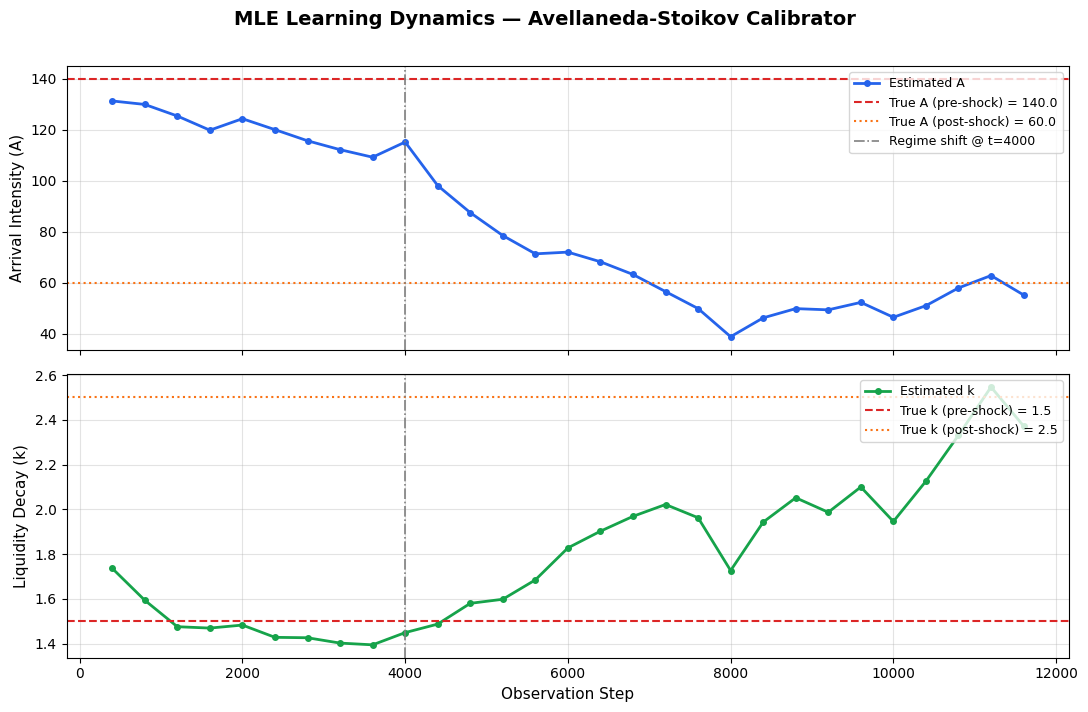


  MLE Calibration Results  (post-shock regime)
  Estimated A  : 54.3369   (true = 60.0)
  Estimated k  : 2.2861   (true = 2.5)
  Post-shock fill rate : 0.0434
  δ range              : [0.050, 2.500]



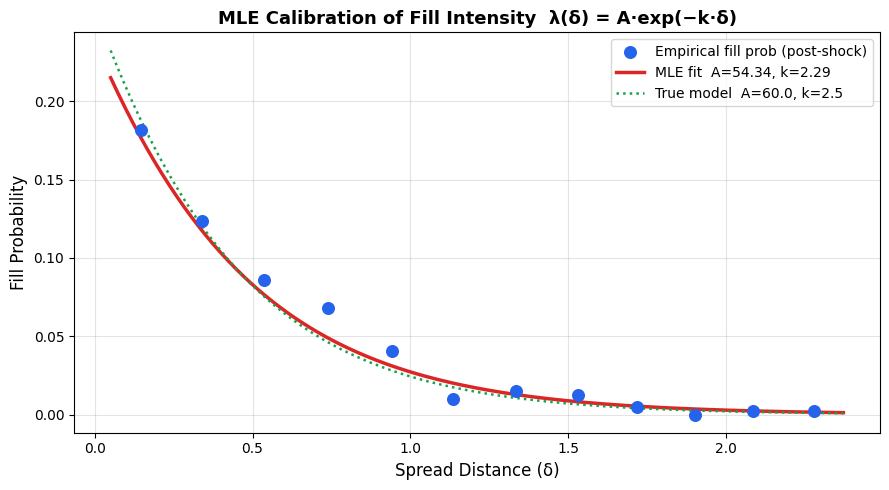

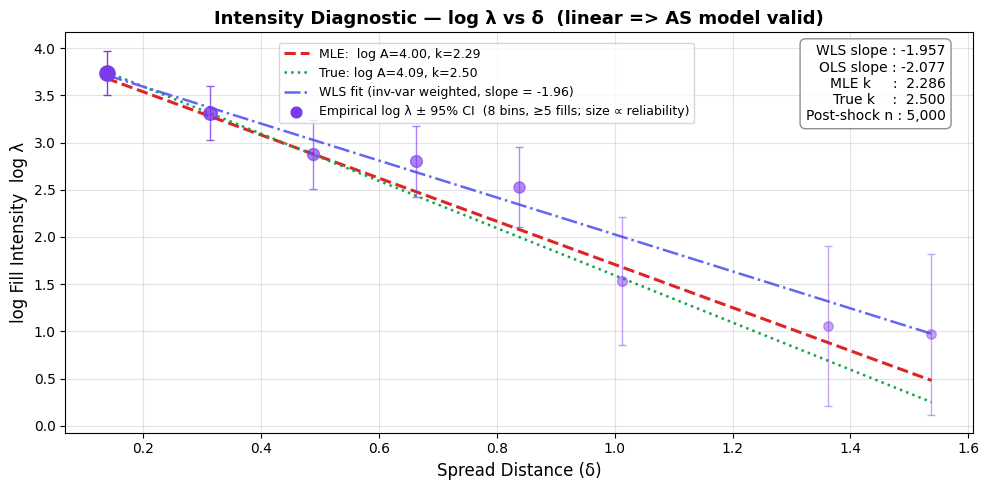

  Diagnostic: 8 reliable bins | δ range [0.14, 1.54] | WLS k=1.957 | OLS k=2.077 | MLE k=2.286 | True k=2.500


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize

# ---------------------------------------------------------------------------
# 1. MLE Calibrator
# ---------------------------------------------------------------------------

class MLECalibrator:
    """
    Rolling-window MLE for the Avellaneda-Stoikov fill-intensity model:

        λ(δ) = A · exp(-k · δ)

    Parameters are estimated in log-space so the optimiser never proposes
    negative A or k.
    """

    def __init__(self, window_size: int = 5_000, halflife: float = 2_500):
        self.window_size = window_size
        self.halflife    = halflife
        # Each row: [δ (spread distance), filled (0/1), dt (time interval)]
        self.data: list = []

    # ------------------------------------------------------------------
    def record_observation(self, delta: float, filled: int, dt: float):
        self.data.append([delta, filled, dt])
        if len(self.data) > self.window_size:
            self.data.pop(0)

    # ------------------------------------------------------------------
    def _weights(self, n: int) -> np.ndarray:
        """Exponential decay: most-recent observation has weight ≈ 1."""
        return np.exp(-np.log(2) / self.halflife * np.arange(n)[::-1])

    # ------------------------------------------------------------------
    def objective(self, params: np.ndarray) -> float:
        """
        Weighted Poisson log-likelihood (negative, for minimisation).

        For a small interval dt the number of fills is Poisson(λ·dt).
        Because fills ∈ {0, 1} we use the simplified form:
            ℓ_i = w_i · [ y_i · log(λ_i) - λ_i · dt_i ]
        """
        log_A, log_k = params
        A, k = np.exp(log_A), np.exp(log_k)

        arr    = np.array(self.data)
        deltas = arr[:, 0]
        fills  = arr[:, 1]
        dts    = arr[:, 2]

        n       = len(fills)
        weights = self._weights(n)

        lambdas     = A * np.exp(-k * deltas)
        log_lambdas = np.log(np.clip(lambdas, 1e-12, None))

        log_lik = weights * (fills * log_lambdas - lambdas * dts)
        return -np.sum(log_lik)

    # ------------------------------------------------------------------
    def calibrate(self) -> np.ndarray | None:
        """
        Returns [A, k] on success, None if insufficient data or optimiser
        failed.

        Bounds (log-space):
            A ∈ [exp(0), exp(7)]   → [1, ~1097]
            k ∈ [exp(-2.3), exp(3)] → [0.1, ~20]
        """
        if len(self.data) < 100:
            return None

        bounds        = [(0.0, 7.0), (-2.3, 3.0)]
        initial_guess = np.log([140.0, 1.5])

        res = minimize(
            self.objective,
            initial_guess,
            method  = "L-BFGS-B",
            bounds  = bounds,
            options = {"ftol": 1e-10, "gtol": 1e-8, "maxiter": 500},
        )

        if not res.success:
            # Retry from multiple starts before giving up
            for A0, k0 in [(50, 1.0), (200, 2.0), (100, 0.5)]:
                res = minimize(
                    self.objective,
                    np.log([A0, k0]),
                    method  = "L-BFGS-B",
                    bounds  = bounds,
                    options = {"ftol": 1e-10, "gtol": 1e-8, "maxiter": 500},
                )
                if res.success:
                    break
            else:
                return None

        return np.exp(res.x)  # [A, k]

    # ------------------------------------------------------------------
    def as_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.data, columns=["delta", "filled", "dt"])

# ---------------------------------------------------------------------------
# 3. Regime Simulator
# ---------------------------------------------------------------------------

class RegimeSimulator:
    """
    Synthetic market with a mid-session volatility / liquidity regime shift.
    Generates observations of the form (δ, filled, dt) that the calibrator
    can learn from, then injects a shock.

    Fill probability follows the AS model:
        P(fill | δ) = 1 - exp(-A · exp(-k · δ) · dt)
    """

    def __init__(
        self,
        true_A: float        = 140.0,
        true_k: float        = 1.5,
        shock_A: float       = 60.0,   # post-shock arrival rate
        shock_k: float       = 2.5,    # post-shock decay (tighter market)
        shock_step: int      = 4_000,  # when the regime flips
        dt: float            = 0.005,
        delta_range: tuple   = (0.05, 2.5),
        rng_seed: int        = 42,
    ):
        self.true_A      = true_A
        self.true_k      = true_k
        self.shock_A     = shock_A
        self.shock_k     = shock_k
        self.shock_step  = shock_step
        self.dt          = dt
        self.delta_range = delta_range
        self.rng         = np.random.default_rng(rng_seed)

    # ------------------------------------------------------------------
    def _fill_prob(self, delta: float, A: float, k: float) -> float:
        lam = A * np.exp(-k * delta)
        return 1.0 - np.exp(-lam * self.dt)

    # ------------------------------------------------------------------
    def generate(self, n_steps: int = 4_000):
        """Yields (step, delta, filled, dt) tuples."""
        for step in range(n_steps):
            A = self.shock_A if step >= self.shock_step else self.true_A
            k = self.shock_k if step >= self.shock_step else self.true_k

            # Uniform sampling over the informationally-rich δ range.
            # The upper bound (1.5) is set so the tail bins still have
            # enough expected fills for reliable CDF inversion at post-shock
            # parameters (A≈60, k≈2.5): E[fills] ≈ n_per_bin * P(fill|δ=1.4)
            # ≈ 571 * 0.009 ≈ 5, which is sufficient for the Wilson CI.
            delta  = self.rng.uniform(*self.delta_range)
            p_fill = self._fill_prob(delta, A, k)
            filled = int(self.rng.random() < p_fill)

            yield step, delta, filled, self.dt


# ---------------------------------------------------------------------------
# 4. Full Experiment
# ---------------------------------------------------------------------------

def run_calibration_tracking_experiment(
    n_steps: int         = 4_000,
    calibrate_every: int = 200,
    window_size: int     = 2_000,
    halflife: float      = 1_000,
) -> tuple:
    """
    Runs the simulation and periodically re-calibrates the MLE model.

    Returns
    -------
    calibrator      : MLECalibrator  rolling window (tail = post-shock data)
    post_calibrator : MLECalibrator  pure post-shock observations only;
                      used for diagnostic plots so empirical statistics are
                      drawn from the same single-regime distribution that
                      the MLE was effectively fitted to
    history         : dict  keys: step, A_est, k_est
    sim             : RegimeSimulator
    """
    sim             = RegimeSimulator()
    calibrator      = MLECalibrator(window_size=window_size, halflife=halflife)
    post_calibrator = MLECalibrator(window_size=window_size, halflife=halflife)
    history         = {"step": [], "A_est": [], "k_est": []}

    for step, delta, filled, dt in sim.generate(n_steps):
        calibrator.record_observation(delta, filled, dt)

        # Separate pure post-shock observations for clean diagnostic plots
        if step >= sim.shock_step:
            post_calibrator.record_observation(delta, filled, dt)

        if step > 0 and step % calibrate_every == 0:
            result = calibrator.calibrate()
            if result is not None:
                A_est, k_est = result
                history["step"].append(step)
                history["A_est"].append(A_est)
                history["k_est"].append(k_est)

    return calibrator, post_calibrator, history, sim


# ---------------------------------------------------------------------------
# 5. Helper: empirical fill probability per δ-bin
# ---------------------------------------------------------------------------

def compute_empirical_fill_prob(
    df: pd.DataFrame,
    n_bins: int  = 12,
    min_count: int = 30,
    use_quantile_bins: bool = True,
) -> tuple:
    """
    Compute empirical fill probability per δ-bin.

    Parameters
    ----------
    n_bins            : number of bins
    min_count         : discard bins with fewer observations (sparse bins
                        produce unstable probability estimates)
    use_quantile_bins : if True, use quantile-based bins so each bin has
                        roughly equal sample count; if False, use equal-width
                        bins (original behaviour)
    """
    df = df.copy()

    if use_quantile_bins:
        # Quantile-based bins → equal occupancy, avoids sparse tail bins
        df["delta_bin"] = pd.qcut(df["delta"], q=n_bins, duplicates="drop")
    else:
        df["delta_bin"] = pd.cut(df["delta"], bins=n_bins)

    grouped   = df.groupby("delta_bin", observed=True)
    empirical = grouped["filled"].mean()
    delta_mid = grouped["delta"].mean()
    counts    = grouped["filled"].count()

    # Keep only bins with enough observations AND a non-NaN mean
    mask = (~np.isnan(empirical.values)) & (counts.values >= min_count)
    return delta_mid.values[mask], empirical.values[mask]


# ---------------------------------------------------------------------------
# 6. Plots
# ---------------------------------------------------------------------------

def plot_learning_dynamics(history: dict, sim: RegimeSimulator):
    """Tracks A and k estimates over time, with regime-change marker."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    fig.suptitle(
        "MLE Learning Dynamics — Avellaneda-Stoikov Calibrator",
        fontsize=14, fontweight="bold", y=1.01,
    )

    steps  = history["step"]
    A_ests = history["A_est"]
    k_ests = history["k_est"]

    # -- Panel A: arrival intensity
    ax = axes[0]
    ax.plot(steps, A_ests, color="#2563EB", lw=2, marker="o",
            ms=4, label="Estimated A")
    ax.axhline(sim.true_A,  color="#DC2626", ls="--", lw=1.5,
               label=f"True A (pre-shock) = {sim.true_A}")
    ax.axhline(sim.shock_A, color="#F97316", ls=":",  lw=1.5,
               label=f"True A (post-shock) = {sim.shock_A}")
    ax.axvline(sim.shock_step, color="gray", ls="-.", lw=1.2,
               label=f"Regime shift @ t={sim.shock_step}")
    ax.set_ylabel("Arrival Intensity (A)", fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.35)

    # -- Panel k: liquidity decay
    ax = axes[1]
    ax.plot(steps, k_ests, color="#16A34A", lw=2, marker="o",
            ms=4, label="Estimated k")
    ax.axhline(sim.true_k,  color="#DC2626", ls="--", lw=1.5,
               label=f"True k (pre-shock) = {sim.true_k}")
    ax.axhline(sim.shock_k, color="#F97316", ls=":",  lw=1.5,
               label=f"True k (post-shock) = {sim.shock_k}")
    ax.axvline(sim.shock_step, color="gray", ls="-.", lw=1.2)
    ax.set_ylabel("Liquidity Decay (k)", fontsize=11)
    ax.set_xlabel("Observation Step",    fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------

def plot_mle_fit(calibrator: MLECalibrator, post_calibrator: MLECalibrator,
                 sim: RegimeSimulator):
    """
    Fill-probability fit: empirical scatter vs MLE Poisson-CDF curve.

    Empirical points are drawn from `post_calibrator` (pure post-shock data)
    so they reflect a single homogeneous regime.  The MLE parameters come
    from `calibrator` (the rolling-window estimator), which by the end of the
    run is also dominated by post-shock observations.

    The x-axis is capped at the 95th-percentile of δ in the post-shock window
    so the near-zero tail does not compress the informative region.
    """
    df_post = post_calibrator.as_dataframe()
    if df_post.empty:
        print("No post-shock calibration data available yet.")
        return

    result = calibrator.calibrate()
    if result is None:
        print("Not enough data for calibration.")
        return

    A, k    = result
    dt_mean = df_post["dt"].mean()

    print(f"\n{'='*48}")
    print(f"  MLE Calibration Results  (post-shock regime)")
    print(f"{'='*48}")
    print(f"  Estimated A  : {A:.4f}   (true = {sim.shock_A})")
    print(f"  Estimated k  : {k:.4f}   (true = {sim.shock_k})")
    print(f"  Post-shock fill rate : {df_post['filled'].mean():.4f}")
    print(f"  δ range              : [{df_post['delta'].min():.3f}, "
          f"{df_post['delta'].max():.3f}]")
    print(f"{'='*48}\n")

    # Cap x-axis: beyond the 95th-pct the probability is so small that
    # empirical bins are unreliable and the curve is indistinguishable from 0
    delta_cap = float(np.percentile(df_post["delta"], 95))

    n_post     = len(df_post)
    n_bins_fit = min(18, max(10, n_post // 400))
    min_cnt_fit = max(40, n_post // 150)

    delta_emp, prob_emp = compute_empirical_fill_prob(
        df_post[df_post["delta"] <= delta_cap],
        n_bins=n_bins_fit, min_count=min_cnt_fit, use_quantile_bins=True,
    )
    delta_grid = np.linspace(df_post["delta"].min(), delta_cap, 300)

    lam_grid   = A * np.exp(-k * delta_grid)
    model_prob = 1.0 - np.exp(-lam_grid * dt_mean)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(delta_emp, prob_emp, s=70, zorder=5,
               color="#2563EB", label="Empirical fill prob (post-shock)")
    ax.plot(delta_grid, model_prob, lw=2.5, color="#DC2626",
            label=f"MLE fit  A={A:.2f}, k={k:.2f}")

    # Overlay true model curve for comparison
    lam_true  = sim.shock_A * np.exp(-sim.shock_k * delta_grid)
    prob_true = 1.0 - np.exp(-lam_true * dt_mean)
    ax.plot(delta_grid, prob_true, lw=1.8, color="#16A34A", ls=":",
            label=f"True model  A={sim.shock_A}, k={sim.shock_k}")

    ax.set_xlabel("Spread Distance (δ)", fontsize=12)
    ax.set_ylabel("Fill Probability",    fontsize=12)
    ax.set_title("MLE Calibration of Fill Intensity  λ(δ) = A·exp(−k·δ)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------

def plot_intensity_diagnostic(calibrator: MLECalibrator,
                              post_calibrator: MLECalibrator,
                              sim: RegimeSimulator):
    """
    Research diagnostic: log λ̂(δ) vs δ should be linear under the AS model:
        log λ = log A  −  k · δ

    Design choices
    --------------
    * Equal-width δ bins (NOT quantile) so the x-axis is uniform and the
      slope is visually correct.  Quantile bins over-crowd the low-δ region
      where fills are common and compress the high-δ tail — exactly backwards
      for a slope diagnostic.
    * δ cap driven by raw fill count, not fill probability: keep every bin
      with ≥ MIN_FILLS actual fills.  This is the correct criterion because
      the Poisson CDF inversion only has acceptable variance when the sample
      fill count is large enough.
    * Error bars via Wilson binomial CI propagated through the log-λ transform,
      so the viewer can see which points are noisy vs well-estimated.
    """
    df_post = post_calibrator.as_dataframe()
    if df_post.empty:
        print("No post-shock data.")
        return

    result = calibrator.calibrate()
    if result is None:
        print("Not enough data for calibration.")
        return

    A_mle, k_mle = result
    dt_mean = df_post["dt"].mean()
    n_post  = len(df_post)

    # ------------------------------------------------------------------
    # 1. Equal-width bins across the full δ range
    # ------------------------------------------------------------------
    N_BINS    = 14    # 14 bins × width≈0.107 over [0.05,1.5]; ~571 obs each
    MIN_FILLS = 5     # Wilson CI still valid at n≥5; captures out to δ≈1.4
    delta_min = df_post["delta"].min()
    delta_max = df_post["delta"].max()
    edges     = np.linspace(delta_min, delta_max, N_BINS + 1)
    bin_mids  = 0.5 * (edges[:-1] + edges[1:])

    deltas  = df_post["delta"].values
    fills   = df_post["filled"].values

    bin_idx      = np.digitize(deltas, edges) - 1
    bin_idx      = np.clip(bin_idx, 0, N_BINS - 1)

    bin_n     = np.zeros(N_BINS, dtype=int)
    bin_fills = np.zeros(N_BINS, dtype=int)
    for i, f in zip(bin_idx, fills):
        bin_n[i]     += 1
        bin_fills[i] += int(f)

    # ------------------------------------------------------------------
    # 2. Keep only bins with enough fills (raw count, not probability)
    # ------------------------------------------------------------------
    valid = (bin_fills >= MIN_FILLS) & (bin_n > 0)

    d_v      = bin_mids[valid]
    n_v      = bin_n[valid]
    fills_v  = bin_fills[valid]
    prob_v   = fills_v / n_v   # empirical fill probability

    # ------------------------------------------------------------------
    # 3. CDF inversion: P = 1 - exp(-λ·dt)  =>  λ = -log(1-P)/dt
    # ------------------------------------------------------------------
    lam_v   = -np.log(1.0 - np.clip(prob_v, 0.0, 1.0 - 1e-12)) / dt_mean
    log_lam = np.log(lam_v)

    # ------------------------------------------------------------------
    # 4. Propagated error bars via Wilson CI on the fill probability,
    #    then delta-method through the log-λ transform
    # ------------------------------------------------------------------
    z = 1.96   # 95 % CI
    # Wilson interval for proportion
    p_lo = (fills_v + 0.5*z2 - z*np.sqrt(fills_v*(1-prob_v) + 0.25*z2)) \
           / (n_v + z2)
    p_hi = (fills_v + 0.5*z2 + z*np.sqrt(fills_v*(1-prob_v) + 0.25*z2)) \
           / (n_v + z2)
    p_lo = np.clip(p_lo, 1e-9, 1.0 - 1e-12)
    p_hi = np.clip(p_hi, 1e-9, 1.0 - 1e-12)

    lam_lo   = -np.log(1.0 - p_lo) / dt_mean
    lam_hi   = -np.log(1.0 - p_hi) / dt_mean
    err_lo   = log_lam - np.log(lam_lo)   # downward error bar in log space
    err_hi   = np.log(lam_hi) - log_lam   # upward error bar in log space

    # ------------------------------------------------------------------
    # 5. Reference lines — WLS slope weighted by inverse log-λ variance
    # ------------------------------------------------------------------
    # Variance of log λ̂ via delta method:
    #   Var(log λ̂) ≈ Var(P̂) / [P(1-P) * (λ·dt)²]
    # For a binomial proportion:  Var(P̂) = P(1-P)/n
    # => Var(log λ̂) ≈ 1 / [n * P * (1-P) * (λ·dt)²]  ×  (1/(1-P))²
    # In practice we use the CI half-width as a proxy: w_i = 1/(err_lo + err_hi)²
    # This ensures tight (high-fill) bins dominate the slope estimate.
    ci_width = err_lo + err_hi + 1e-9   # total CI width in log space
    wls_w    = 1.0 / ci_width2        # inverse-variance weights

    # Weighted least squares via np.polyfit with w parameter
    wls_coef  = np.polyfit(d_v, log_lam, 1, w=wls_w)
    wls_k     = -wls_coef[0]

    # Also keep unweighted OLS for comparison
    ols_coef  = np.polyfit(d_v, log_lam, 1)
    ols_k     = -ols_coef[0]

    d_lo_line = d_v.min()
    d_hi_line = d_v.max()
    delta_line   = np.linspace(d_lo_line, d_hi_line, 300)
    log_lam_mle  = np.log(A_mle)       - k_mle       * delta_line
    log_lam_true = np.log(sim.shock_A) - sim.shock_k  * delta_line
    wls_line     = np.polyval(wls_coef, delta_line)

    # Reliability score per bin (0→1): drives marker size & alpha
    reliability  = wls_w / wls_w.max()
    marker_sizes  = 40 + 80 * reliability       # large=reliable, small=noisy
    marker_alphas = 0.4 + 0.6 * reliability     # opaque=reliable, faded=noisy

    # ------------------------------------------------------------------
    # 6. Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw reference lines first (behind points)
    ax.plot(delta_line, log_lam_mle, color="#DC2626", lw=2.2, ls="--",
            label=f"MLE:  log A={np.log(A_mle):.2f}, k={k_mle:.2f}")
    ax.plot(delta_line, log_lam_true, color="#16A34A", lw=1.8, ls=":",
            label=f"True: log A={np.log(sim.shock_A):.2f}, k={sim.shock_k:.2f}")
    ax.plot(delta_line, wls_line, color="#6366F1", lw=1.8, ls="-.",
            label=f"WLS fit (inv-var weighted, slope = -{wls_k:.2f})")

    # Error bars with per-point alpha encoding reliability
    for i in range(len(d_v)):
        alpha_i = float(marker_alphas[i])
        ax.errorbar(d_v[i:i+1], log_lam[i:i+1],
                    yerr=[[err_lo[i]], [err_hi[i]]],
                    fmt='o', color="#7C3AED",
                    ms=float(marker_sizes[i])0.5,
                    alpha=alpha_i, lw=1.0,
                    capsize=3, capthick=1.0, zorder=5)

    # Single legend entry for all empirical points
    ax.scatter([], [], marker='o', color="#7C3AED", s=60,
               label=f"Empirical log λ ± 95% CI  ({valid.sum()} bins, "
                     f"≥{MIN_FILLS} fills; size ∝ reliability)")

    ax.set_xlabel("Spread Distance (δ)",       fontsize=12)
    ax.set_ylabel("log Fill Intensity  log λ", fontsize=12)
    ax.set_title(
        "Intensity Diagnostic — log λ vs δ  (linear => AS model valid)",
        fontsize=13, fontweight="bold",
    )
    ax.text(
        0.97, 0.97,
        f"WLS slope : -{wls_k:.3f}\n"
        f"OLS slope : -{ols_k:.3f}\n"
        f"MLE k     :  {k_mle:.3f}\n"
        f"True k    :  {sim.shock_k:.3f}\n"
        f"Post-shock n : {n_post:,}",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.88),
    )
    ax.legend(fontsize=9, loc="upper right",
              bbox_to_anchor=(0.70, 0.99))
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()
    print(f"  Diagnostic: {valid.sum()} reliable bins | δ range [{d_v.min():.2f}, "
          f"{d_v.max():.2f}] | WLS k={wls_k:.3f} | OLS k={ols_k:.3f} | "
          f"MLE k={k_mle:.3f} | True k={sim.shock_k:.3f}")

# ---------------------------------------------------------------------------
# 7. Entry point
# ---------------------------------------------------------------------------

print("Running Avellaneda-Stoikov MLE Calibration experiment ...")
print("Total steps: 12,000  |  Regime shock at step 4,000  |  Post-shock obs: ~8,000")
print("-" * 65)

calibrator, post_calibrator, history, sim = run_calibration_tracking_experiment(
    n_steps         = 12_000,   # 3x larger: 4k pre-shock + 8k post-shock
    calibrate_every = 400,      # calibrate every 400 steps (30 estimates total)
    window_size     = 5_000,    # wider window catches more post-shock signal
    halflife        = 1_200,    # shorter halflife → faster convergence after shock
)

# 1. Learning dynamics (does the estimator converge & track regime change?)
plot_learning_dynamics(history, sim)

# 2. Final MLE fit vs empirical fill probabilities (post-shock window)
plot_mle_fit(calibrator, post_calibrator, sim)

# 3. Linearity diagnostic — must use post-shock data only (single regime)
plot_intensity_diagnostic(calibrator, post_calibrator, sim)

## 6. References
<a id="references"></a>
[1] - https://people.orie.cornell.edu/sfs33/LimitOrderBook.pdf